# Семинар 1. Линейная регрессия

#### Шаг 1. Загрузка датасета и вывод на экран

In [2]:
import pandas as pd
df = pd.read_csv('delivery_dataset.csv')
print(df)

    Дата заказа (ГГГГ-ММ-ДД) Шифр заказа (ID)  Расстояние до клиента (в км)  \
0                 2026-09-08    ORD-202608001                          11.3   
1                 2026-08-29    ORD-202608002                           7.3   
2                 2026-08-15    ORD-202608003                           2.2   
3                 2026-08-08    ORD-202608004                           0.9   
4                 2026-08-21    ORD-202608005                          12.3   
..                       ...              ...                           ...   
495               2026-08-12    ORD-202608496                           5.2   
496               2026-08-09    ORD-202608497                          10.0   
497               2026-08-07    ORD-202608498                           5.5   
498               2026-08-28    ORD-202608499                           7.1   
499               2026-08-14    ORD-202608500                           1.8   

     Количество позиций в чеке (в шт.)  Балл пробок

#### Шаг2. Разделение выборки на тренировочную, валидационную и тестовую с выбором нужных столбцов:
* в тренировочной: 300 первых заказов;
* в валидационной: 100 следующих; 
* в тестовой: 100 последних.

In [3]:
train = df.iloc[0:300]
val = df.iloc[300:400]
test = df.iloc[400:500]

X_train = train[['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']]
y_train = train['Время доставки (в минутах)']

X_val = val[['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']]
y_val = val['Время доставки (в минутах)']

X_test =test[['Расстояние до клиента (в км)', 'Количество позиций в чеке (в шт.)', 'Балл пробок на дорогах (в баллах)', 'Погода (в градусах Цельсия)', 'Этаж доставки (в этажах)']]
y_test = test['Время доставки (в минутах)']


#### Шаг 3. Установка sklearn чтобы обучать модель линейной регрессии через Ridge

In [4]:
!pip install scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


#### Шаг 4. Обучение модели линейной регрессии на тренировочной выборке с помощью Ridge и sparse_cg

In [5]:
from sklearn.linear_model import Ridge

model = Ridge(alpha=1.0, solver='sparse_cg')

model.fit(X_train, y_train)

y_pred_val = model.predict(X_val)

def SSE(y_val, y_pred):
    err = 0
    for i in range(len(y_pred)):
        err += (y_val.iloc[i] - y_pred[i]) ** 2
    return err

er = SSE(y_val, y_pred_val)
print(er)

2078.2902932318993


In [6]:
%pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


#### Шаг 5. Вывод на экран графиков ошибок (SSE, MSE, RMSE) в зависимости от итераций для train и val выборок.

Остановка по невязке на итерации 7, ||r|| = 2.01e-09


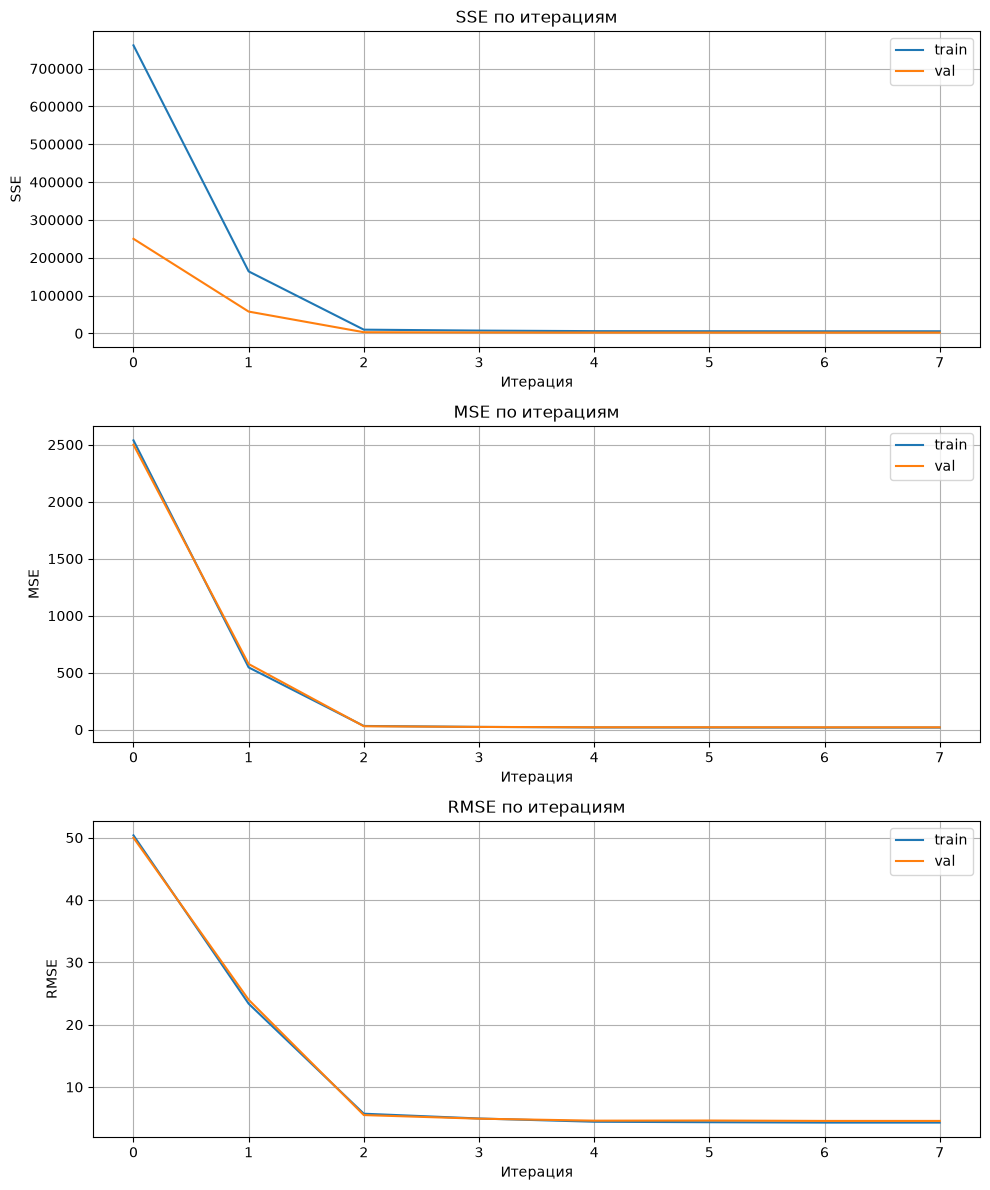


std(y_train) = 26.5210
RMSE_val (финал) = 4.5591
SSE_train (финал) = 5529.1344
SSE_val (финал) = 2078.5052
Число итераций: 8


In [7]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

arr_X_train_1 = X_train.to_numpy(dtype=float)
arr_X_val_1   = X_val.to_numpy(dtype=float)
arr_y_train_1 = y_train.to_numpy(dtype=float)
arr_y_val_1   = y_val.to_numpy(dtype=float)

arr_X_train = np.insert(arr_X_train_1, obj=0, values=1, axis=1)  # (100, 5)
arr_X_val   = np.insert(arr_X_val_1,   obj=0, values=1, axis=1)  # (50, 5)

m = len(arr_y_train_1)
n = arr_X_train.shape[1]

A = arr_X_train.T @ arr_X_train
b = arr_X_train.T @ arr_y_train_1

w = np.zeros(n)

max_iter = 1000
epsilon  = 1e-6 

train_sse_list,  val_sse_list  = [], []
train_mse_list,  val_mse_list  = [], []
train_rmse_list, val_rmse_list = [], []

r = b - A @ w
p = r.copy()

for it in range(max_iter):
    y_pred_train = arr_X_train @ w
    err_train = y_pred_train - arr_y_train_1
    sse_tr  = np.sum(err_train ** 2)
    mse_tr  = sse_tr / m
    rmse_tr = np.sqrt(mse_tr)
    train_sse_list.append(sse_tr)
    train_mse_list.append(mse_tr)
    train_rmse_list.append(rmse_tr)

    y_pred_val = arr_X_val @ w
    err_val = y_pred_val - arr_y_val_1
    sse_v  = np.sum(err_val ** 2)
    mse_v  = sse_v / len(arr_y_val_1)
    rmse_v = np.sqrt(mse_v)
    val_sse_list.append(sse_v)
    val_mse_list.append(mse_v)
    val_rmse_list.append(rmse_v)

    if np.linalg.norm(r) < epsilon:
        print(f"Остановка по невязке на итерации {it}, ||r|| = {np.linalg.norm(r):.2e}")
        break

    Ap = A @ p
    alpha = (r @ r) / (p @ Ap)

    w = w + alpha * p
    r_new = r - alpha * Ap
    beta = (r_new @ r_new) / (r @ r)
    p = r_new + beta * p
    r = r_new
else:
    print(f"Достигнут max_iter = {max_iter}, ||r|| = {np.linalg.norm(r):.2e}")

iters = range(len(train_sse_list))

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

axes[0].plot(iters, train_sse_list, label='train')
axes[0].plot(iters, val_sse_list,   label='val')
axes[0].set_title('SSE по итерациям')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('SSE')
axes[0].legend()
axes[0].grid(True)
axes[1].plot(iters, train_mse_list, label='train')
axes[1].plot(iters, val_mse_list,   label='val')
axes[1].set_title('MSE по итерациям')
axes[1].set_xlabel('Итерация')
axes[1].set_ylabel('MSE')
axes[1].legend()
axes[1].grid(True)
axes[2].plot(iters, train_rmse_list, label='train')
axes[2].plot(iters, val_rmse_list,   label='val')
axes[2].set_title('RMSE по итерациям')
axes[2].set_xlabel('Итерация')
axes[2].set_ylabel('RMSE')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

print(f"\nstd(y_train) = {np.std(arr_y_train_1):.4f}")
print(f"RMSE_val (финал) = {val_rmse_list[-1]:.4f}")
print(f"SSE_train (финал) = {train_sse_list[-1]:.4f}")
print(f"SSE_val (финал) = {val_sse_list[-1]:.4f}")
print(f"Число итераций: {len(train_sse_list)}")

#### Шаг 6. Применение модели на тестовой выборке

In [8]:
import pandas as pd
import numpy as np

arr_X_test_1 = X_test.to_numpy(dtype=float)
arr_X_test   = np.insert(arr_X_test_1, obj=0, values=1, axis=1)
arr_y_test   = y_test.to_numpy(dtype=float)

y_predict = arr_X_test @ w

test_ids = X_test.index

result = pd.DataFrame({
    'id':        test_ids,
    'y_predict': y_predict,
    'y_real':    arr_y_test,
    'diff':      y_predict - arr_y_test,
})

print(result)
result.to_csv('test_predictions.csv', index=False, encoding='utf-8-sig')
print("\nТаблица сохранена в файл test_predictions.csv")

     id  y_predict  y_real      diff
0   400  33.066235    33.9 -0.833765
1   401  33.125508    33.1  0.025508
2   402  20.852183    16.3  4.552183
3   403  34.385205    34.7 -0.314795
4   404  17.562288    13.3  4.262288
..  ...        ...     ...       ...
95  495  30.261688    28.9  1.361688
96  496  54.525097    48.0  6.525097
97  497  28.605027    27.0  1.605027
98  498  41.576744    40.4  1.176744
99  499  22.878354    26.3 -3.421646

[100 rows x 4 columns]

Таблица сохранена в файл test_predictions.csv


#### Шаг 7. RMSE на тестовой выборке

In [ ]:
import numpy as np

err_test = y_predict - arr_y_test

m_test    = len(arr_y_test)
sse_test  = np.sum(err_test ** 2)
mse_test  = sse_test / m_test   
rmse_test = np.sqrt(mse_test)

print(f"SSE_test  = {sse_test:.4f}")
print(f"MSE_test  = {mse_test:.4f}")
print(f"RMSE_test = {rmse_test:.4f}")
print(f"std(y_test)     = {np.std(arr_y_test):.4f}")
print(f"RMSE_test / std = {rmse_test / np.std(arr_y_test):.4f}")

print("\nСравнение с валидацией:")
print(f"RMSE_val  = 4.5591")
print(f"RMSE_test = {rmse_test:.4f}")
print(f"Разница   = {rmse_test - 4.5591:+.4f}")

SSE_test  = 2333.9835
MSE_test  = 23.3398
RMSE_test = 4.8311
std(y_test)     = 25.8032
RMSE_test / std = 0.1872

Сравнение с валидацией:
RMSE_val  = 4.5591
RMSE_test = 4.8311
Разница   = +0.2720
